# 10 — Evaluating Generative Models: FID and BLEU

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what **FID** (Fréchet Inception Distance) measures and **compute a Fréchet distance** yourself on image sets of graded quality
- **Compute BLEU scores** with NLTK on generated-text examples of graded quality
- Interpret both metrics: what "lower FID" / "higher BLEU" actually certify — and what they miss

## 🔗 Prerequisites

- ✅ Examples 01–09 (you now train generative models; this notebook is how you *grade* them)
- ✅ NumPy, scikit-learn

---

## Introduction

Looking at samples (example 09) does not scale. The field's standard automatic metrics are:

- **FID** for images: fit a Gaussian (mean μ, covariance Σ) to *feature vectors* of real images and of generated images, then compute the Fréchet distance
  **FID = ‖μ_r − μ_g‖² + Tr(Σ_r + Σ_g − 2(Σ_r Σ_g)^{1/2})** — lower is better.
  The "Inception" in the name: production FID extracts those features with a pretrained InceptionV3 network. To keep this notebook download-free, we use **PCA features on 8×8 digits instead of Inception features** — the Fréchet computation itself is *exactly* the real one, so we label our numbers "Fréchet distance (PCA features)", not official FID values.
- **BLEU** for text: modified n-gram precision of a candidate against reference texts, with a brevity penalty — between 0 and 1, higher is better.


## Part 1 — Fréchet Distance on Image Sets of Graded Quality

The honest way to test a metric: feed it sets whose quality we already know, and check that it separates them sensibly — a real held-out set should score near 0, corrupted sets higher, and garbage highest. We compare four "generated" sets against a held-out real set:

1. **real** — a second sample of true digits (a perfect generator would look like this)
2. **blurred** — real digits, Gaussian-blurred
3. **noisy** — real digits + pixel noise
4. **noise** — pure random pixels (a worthless generator)


candidate set      Frechet distance (PCA features) — lower is better
real (held-out)          0.06
blurred                  2.29
noisy                    0.26
pure noise               3.82


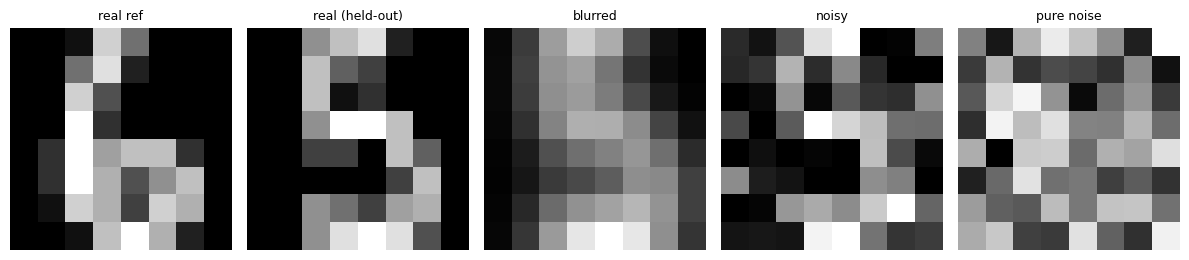

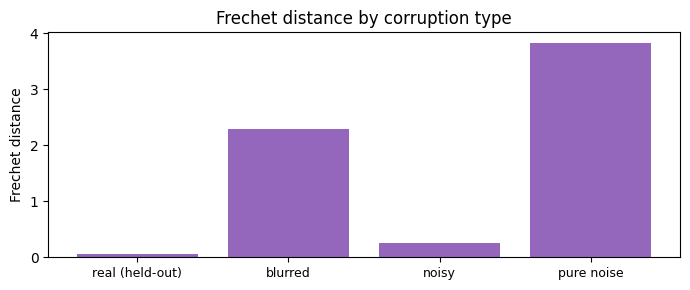


Read the table: a held-out real set scores near 0, corruption raises the
distance, and pure noise scores far worse — the ordering FID is built to give.


In [1]:
# WHAT/WHY: implement the exact FID formula (Frechet distance between
# Gaussian fits of feature vectors) and verify it separates image sets of
# KNOWN quality: real scores near 0, corrupted sets higher, pure noise worst.
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from scipy.ndimage import gaussian_filter
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)

# ── Real digit images (1797 samples of 8×8 pixels, values 0..16) ──────────
digits = load_digits()
X = digits.images / 16.0                      # scale to [0, 1]
rng.shuffle(X)
real_ref, real_other = X[:800], X[800:1600]   # two disjoint real sets

# ── Candidate "generated" sets of graded (known) quality ──────────────────
blurred = np.stack([gaussian_filter(img, sigma=0.9) for img in real_other])
noisy   = np.clip(real_other + rng.normal(0, 0.25, real_other.shape), 0, 1)
noise   = rng.uniform(0, 1, real_other.shape)          # worthless generator

# ── Feature extractor: PCA fitted on real reference images ────────────────
# (Production FID uses InceptionV3's 2048-dim features here instead.)
pca = PCA(n_components=32).fit(real_ref.reshape(len(real_ref), -1))
def features(imgs):
    return pca.transform(imgs.reshape(len(imgs), -1))

# ── The FID formula, verbatim ─────────────────────────────────────────────
def frechet_distance(feat_real, feat_gen):
    mu_r, mu_g = feat_real.mean(0), feat_gen.mean(0)
    sigma_r = np.cov(feat_real, rowvar=False)
    sigma_g = np.cov(feat_gen,  rowvar=False)
    covmean = sqrtm(sigma_r @ sigma_g).real       # matrix square root
    return ((mu_r - mu_g) ** 2).sum() + np.trace(sigma_r + sigma_g - 2 * covmean)

# ── Score every candidate set against the real reference ──────────────────
feat_ref = features(real_ref)
results = {}
for name, imgs in [("real (held-out)", real_other), ("blurred", blurred),
                   ("noisy", noisy), ("pure noise", noise)]:
    results[name] = frechet_distance(feat_ref, features(imgs))

print("candidate set      Frechet distance (PCA features) — lower is better")
for name, val in results.items():
    print(f"{name:<18} {val:10.2f}")

# ── Show one image per set + the scores as a bar chart ────────────────────
fig, axes = plt.subplots(1, 5, figsize=(12, 2.6))
for ax, (name, imgs) in zip(axes, [("real ref", real_ref), ("real (held-out)", real_other),
                                   ("blurred", blurred), ("noisy", noisy), ("pure noise", noise)]):
    ax.imshow(imgs[0], cmap='gray'); ax.set_title(name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(results)), list(results.values()), color='tab:purple')
ax.set_xticks(range(len(results))); ax.set_xticklabels(list(results.keys()), fontsize=9)
ax.set_ylabel("Frechet distance"); ax.set_title("Frechet distance by corruption type")
plt.tight_layout(); plt.show()

print("\nRead the table: a held-out real set scores near 0, corruption raises the")
print("distance, and pure noise scores far worse — the ordering FID is built to give.")


## Part 2 — BLEU on Text of Graded Quality

Same honest test for text: candidates whose quality ranking we know, scored against reference translations with NLTK's `sentence_bleu` (smoothing method 1, standard for short sentences).


In [2]:
# WHAT/WHY: compute real BLEU scores with NLTK on candidates of known,
# graded quality — from a perfect match down to unrelated text — and check
# the scores fall in that order.
%pip install nltk -q
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1   # avoids zero scores on short sentences

# ── One reference "translation" (tokenized) ───────────────────────────────
reference = [["the", "cat", "sat", "on", "the", "warm", "mat", "near", "the", "door"]]

# ── Candidates of graded quality, best to worst ───────────────────────────
candidates = {
    "exact match":     ["the", "cat", "sat", "on", "the", "warm", "mat", "near", "the", "door"],
    "close paraphrase":["the", "cat", "sat", "on", "the", "warm", "mat", "by",   "the", "door"],
    "partial overlap": ["a",   "cat", "was", "on", "the", "mat"],
    "unrelated":       ["quantum", "computing", "will", "change", "cryptography", "forever"],
}

# ── Score each candidate (4-gram BLEU, the standard) ──────────────────────
print("candidate           BLEU (0-1, higher is better)")
for name, cand in candidates.items():
    score = sentence_bleu(reference, cand, smoothing_function=smooth)
    print(f"{name:<19} {score:.4f}")

print("\nRead the scores: they fall exactly with quality. Note BLEU's limits — it")
print("rewards n-gram overlap with the reference, so a *valid* but differently")
print("worded output scores low; modern LLM evaluation adds semantic metrics")
print("(BERTScore, human/model grading) on top of BLEU.")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


candidate           BLEU (0-1, higher is better)
exact match         1.0000
close paraphrase    0.7071
partial overlap     0.0527
unrelated           0.0000

Read the scores: they fall exactly with quality. Note BLEU's limits — it
rewards n-gram overlap with the reference, so a *valid* but differently
worded output scores low; modern LLM evaluation adds semantic metrics
(BERTScore, human/model grading) on top of BLEU.


## 📚 References & Further Reading

**Papers:**
- Heusel et al. (2017) — [GANs Trained by a Two Time-Scale Update Rule (introduces FID)](https://arxiv.org/abs/1706.08500)
- Salimans et al. (2016) — [Improved Techniques for Training GANs (Inception Score)](https://arxiv.org/abs/1606.03498)
- Papineni et al. (2002) — [BLEU: a Method for Automatic Evaluation of Machine Translation](https://aclanthology.org/P02-1040/)

**Tools:** [`torchmetrics.image.fid`](https://lightning.ai/docs/torchmetrics/stable/image/frechet_inception_distance.html) computes production FID with the real InceptionV3 features


## 📝 Summary

In **10 — Evaluating Generative Models** you computed both headline metrics yourself: a **Fréchet distance** with the exact FID formula (PCA features standing in for Inception features) that correctly ranked image sets of known quality, and **BLEU scores** that correctly ranked text candidates from exact match down to unrelated (both printed tables above). You also saw each metric's blind spots — FID depends on its feature extractor, BLEU punishes valid paraphrases.
